In [1]:
import polars as pl

In [2]:
# _file = 'qced_maf1e-3_loftee_olink_genes_EURunrelated'
_file = 'qced_maf1e-3_loftee_olink_genes'

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/{_file}.parquet -o /home/dnanexus/data_dir/{_file}.parquet

[===========================================================>] Completed 37,819,413,378 of 37,819,413,378 bytes (100%) /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes.parquett===>                                                      ] Downloaded 3,623,878,656 of 37,819,413,378 bytes (9%) /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes.parquet


In [3]:
b2p = pl.scan_parquet(f'/home/dnanexus/data_dir/{_file}.parquet')
b2p.head().collect()

CHROM,POS,REF,ALT,SAMPLE,GT
str,i64,str,str,str,i8
"""chr10""",20020006,"""C""","""T""","""5317620""",1
"""chr10""",20020007,"""TTTTCTTGC""","""T""","""5546988""",1
"""chr10""",20020010,"""T""","""C""","""2793793""",1
"""chr10""",20020013,"""T""","""G""","""1314475""",1
"""chr10""",20020014,"""G""","""A""","""1722739""",1


In [4]:
(
    b2p
    .with_columns(
        pl.concat_str(
            [
                pl.col("CHROM"),
                pl.lit(":"),
                pl.col("POS").cast(pl.Utf8),
                pl.lit(":"),
                pl.col("REF"),
                pl.lit(":"),
                pl.col("ALT"),
            ]
        ).alias("ID")
    )
    .select(['ID', 'GT'])
    .sink_parquet(f'/home/dnanexus/data_dir/{_file}_variants.parquet', engine='streaming')
)

## Get unique vars and MACs

In [5]:
import polars as pl
import matplotlib.pyplot as plt
from plotnine import *

In [6]:
var_ids = pl.scan_parquet(f'/home/dnanexus/data_dir/{_file}_variants.parquet')
var_ids.head().collect()

ID,GT
str,i8
"""chr10:20020006:C:T""",1
"""chr10:20020007:TTTTCTTGC:T""",1
"""chr10:20020010:T:C""",1
"""chr10:20020013:T:G""",1
"""chr10:20020014:G:A""",1


In [7]:
unq_vars = (
    var_ids
    .rename({c: c.lower() for c in var_ids.collect_schema().names()})
    .group_by('id')
    .agg(
        sc_ukb = pl.len(),
        ac_ukb = pl.sum("gt")
    )
    .sort('ac_ukb')
    .collect(engine='streaming')
)

unq_vars

id,sc_ukb,ac_ukb
str,u64,i64
"""chr10:24723761:C:T""",1,1
"""chr10:24724117:G:A""",1,1
"""chr10:24724233:A:C""",1,1
"""chr10:24724912:G:A""",1,1
"""chr10:24726127:G:A""",1,1
…,…,…
"""chr10:20299159:T:A""",490541,981082
"""chr10:133332317:A:G""",490541,981082
"""chr10:26462576:A:T""",490541,981082


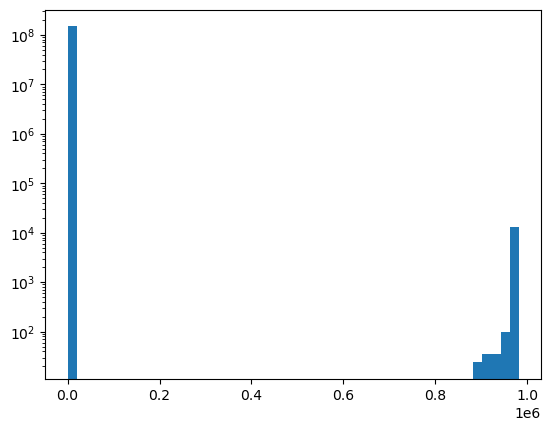

In [8]:
plt.hist(unq_vars['ac_ukb'], bins=50, log=True)
plt.show()

In [9]:
max_ac = unq_vars['ac_ukb'].max()
max_ac

981082

In [10]:
unq_vars = (
    unq_vars
    .with_columns(
        chrom = pl.col("id").str.split(":").list.get(0),
        pos = pl.col("id").str.split(":").list.get(1),
        ref = pl.col("id").str.split(":").list.get(2),
        alt = pl.col("id").str.split(":").list.get(3),
        mac_ukb = (
            pl.when(pl.col('ac_ukb') > int(max_ac/2))
            .then(max_ac + 1 - pl.col('ac_ukb'))
            .otherwise(pl.col('ac_ukb'))
        )
    )
)

unq_vars

id,sc_ukb,ac_ukb,chrom,pos,ref,alt,mac_ukb
str,u64,i64,str,str,str,str,i64
"""chr10:24723761:C:T""",1,1,"""chr10""","""24723761""","""C""","""T""",1
"""chr10:24724117:G:A""",1,1,"""chr10""","""24724117""","""G""","""A""",1
"""chr10:24724233:A:C""",1,1,"""chr10""","""24724233""","""A""","""C""",1
"""chr10:24724912:G:A""",1,1,"""chr10""","""24724912""","""G""","""A""",1
"""chr10:24726127:G:A""",1,1,"""chr10""","""24726127""","""G""","""A""",1
…,…,…,…,…,…,…,…
"""chr10:20299159:T:A""",490541,981082,"""chr10""","""20299159""","""T""","""A""",1
"""chr10:133332317:A:G""",490541,981082,"""chr10""","""133332317""","""A""","""G""",1
"""chr10:26462576:A:T""",490541,981082,"""chr10""","""26462576""","""A""","""T""",1


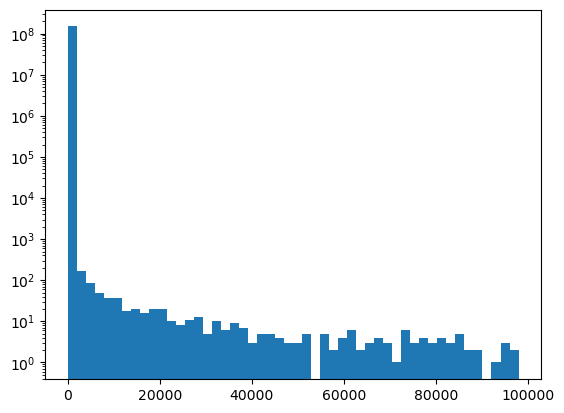

In [11]:
plt.hist(unq_vars['mac_ukb'], bins=50, log=True)
plt.show()

In [12]:
unq_vars.write_parquet(f'/home/dnanexus/data_dir/{_file}_variant_metadata.parquet')

In [13]:
!dx upload /home/dnanexus/data_dir/{_file}_variant_metadata.parquet --path project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/

[===========================================================>] Uploaded 1,626,779,045 of 1,626,779,045 bytes (100%) /home/dnanexus/data_dir/qced_maf1e-3_loftee_olink_genes_variant_metadata.parquet
ID                                file-J5bX0v8Jg0yJ4QBBQJ4ZX73F
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/wgs/qced_maf1e-3_loftee_olink_genes
Name                              qced_maf1e-3_loftee_olink_genes_variant_metadata.parquet
State                             closing
Visibility                        visible
Types                             -
Properties                        -
Tags                              -
Outgoing links                    -
Created                           Sat Jan 17 05:38:57 2026
Created by                        shubhankar
 via the job                      job-J5bQ258Jg0yK4JjJz0BXGZ58
Last modified                     Sat Jan 17 05:39:01 2026
Me